In [50]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from PIL import Image

# Step 1: Download and load the MNIST dataset
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure it's grayscale
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize images to have values between -1 and 1
])

# Download MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 403kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 731kB/s]


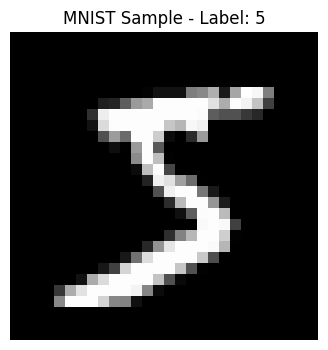

Image shape: torch.Size([1, 28, 28])
Value range: [-1.00, 1.00]


In [51]:
# Step 2: Visualize a sample image
import matplotlib.pyplot as plt

# Get a sample image from the training dataset
sample_idx = 0  # Index of the sample to visualize
sample_img, sample_label = train_dataset[sample_idx]

# Convert tensor to numpy for visualization
sample_img_np = sample_img.squeeze().numpy()  # Remove channel dimension and convert to numpy

# Plot the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_img_np, cmap='gray')
plt.title(f'MNIST Sample - Label: {sample_label}')
plt.axis('off')
plt.show()

# Print image shape and value range
print(f"Image shape: {sample_img.shape}")
print(f"Value range: [{sample_img.min():.2f}, {sample_img.max():.2f}]")

In [52]:

# Step 3: Create image patches (16x16 patches)
def create_image_patches(image, patch_size=14):
    """
    Given an image, create patches of specified size (patch_size x patch_size).
    """
    patches = []
    img = image.numpy().squeeze()  # Convert to numpy array
    for i in range(0, img.shape[0], patch_size):
        for j in range(0, img.shape[1], patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    
    patches = np.array(patches)
    patches = patches.reshape(len(patches), patch_size * patch_size)  # Flatten each patch
    return patches

# Step 4: Create DataLoader for training and testing
def collate_fn(batch):
    # Collate function to group patches into a batch
    images = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    # Create patches for each image
    patch_list = []
    for image in images:
        patches = create_image_patches(image)
        patch_list.append(patches)

    # Stack patches for batch
    patches = torch.tensor(np.array(patch_list))
    labels = torch.tensor(np.array(labels))
    return patches, labels


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=collate_fn)

# View size of train_loader (number of batches)
print(f"Size of train_loader: {len(train_loader)}")

# View size of an example batch in train_loader
for patches, labels in train_loader:
    print("Batch of patches shape:", patches.shape)
    print("Batch of labels shape:", labels.shape)
    break




Size of train_loader: 235
Batch of patches shape: torch.Size([256, 4, 196])
Batch of labels shape: torch.Size([256])


In [53]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, emb_dim, num_heads):
        super().__init__()
        assert emb_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads."

        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        self.qkv_proj = nn.Linear(emb_dim, emb_dim * 3)
        self.out_proj = nn.Linear(emb_dim, emb_dim)

    def forward(self, x):
        B, N, D = x.shape  # (batch_size, sequence_length, embedding_dim)

        # Project to queries, keys, and values
        qkv = self.qkv_proj(x)  # Shape: (B, N, 3*D)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]  # Each: (B, num_heads, N, head_dim)

        # Scaled dot-product attention
        scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)  # (B, num_heads, N, N)
        attn = torch.softmax(scores, dim=-1)  # Attention weights
        out = attn @ v  # (B, num_heads, N, head_dim)

        # Concatenate heads
        out = out.transpose(1, 2).reshape(B, N, D)  # (B, N, D)

        # Final linear projection
        return self.out_proj(out)


In [54]:
class FeedForward(nn.Module):
    def __init__(self, emb_dim, ff_hidden_dim):
        super().__init__()
        self.MLP = nn.Sequential(
            nn.Linear(emb_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, emb_dim)
        )

    def forward(self, x):
        return self.MLP(x)


In [55]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_hidden_dim):
        super().__init__()
        self.attn = MultiHeadSelfAttention(emb_dim, num_heads)
        self.ff = FeedForward(emb_dim, ff_hidden_dim)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x):
        # Self-attention + residual connection + norm
        x = self.norm1(x + self.attn(x))
        # Feedforward + residual connection + norm
        x = self.norm2(x + self.ff(x))
        return x


In [56]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_patches, emb_dim):
        super().__init__()
        # Learnable positional embedding for each patch
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, emb_dim))

    def forward(self, x):
        # x: (B, num_patches, emb_dim)
        return x + self.pos_embedding


In [57]:
class CustomTransformerEncoder(nn.Module):
    def __init__(self, patch_dim, emb_dim, num_heads, ff_hidden_dim, num_layers, num_classes, num_patches):
        super().__init__()

        # Project patch to embedding dimension
        self.patch_proj = nn.Linear(patch_dim, emb_dim)
        self.pos_enc = PositionalEncoding(num_patches, emb_dim)

        # Stacked transformer blocks
        self.encoder_blocks = nn.Sequential(
            *[TransformerEncoderBlock(emb_dim, num_heads, ff_hidden_dim) for _ in range(num_layers)]
        )

        # Classification head
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # x: (B, num_patches, patch_dim)
        x = self.patch_proj(x)  # (B, num_patches, emb_dim)
        x = self.pos_enc(x)     # Add positional encodings
        x = self.encoder_blocks(x)  # (B, num_patches, emb_dim)

        x = x.mean(dim=1)  # Global average pooling across patches
        return self.classifier(x)


In [58]:
import wandb
import torch
from datetime import datetime

def train_model(model, train_loader, test_loader, optimizer, criterion, device, num_epochs=10):
    """
    Train the model, logging metrics to W&B.
    
    Args:
        model: The model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for testing data
        optimizer: The optimizer to use (e.g., Adam)
        criterion: The loss function (e.g., CrossEntropyLoss)
        device: The device to train the model on ('cuda' or 'cpu')
        num_epochs: The number of epochs to train for
        run_name: The name of the W&B run
    """
    model.to(device)

    timestamp = datetime.now().strftime("%H:%M:%S")
    run_name = f"run-{timestamp}"

    # Initialize W&B logging
    wandb.init(entity="emilengdahl", project="ImageTransformer", config={
        "epochs": num_epochs,
        "batch_size": train_loader.batch_size,
        "model": "ImageTransformer",  # Adjust this to match your model's name
        "optimizer": "Adam",
        "lr": optimizer.param_groups[0]['lr']
    }, name=run_name, reinit=True, id=None)

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for patches, labels in train_loader:
            patches = patches.to(device).float()
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(patches)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        # Calculate training accuracy
        acc = correct / total

        # Log training loss and accuracy to W&B
        wandb.log({
            "train_loss": total_loss / len(train_loader),
            "train_accuracy": acc,
            "epoch": epoch + 1
        })

        # Print training progress
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")

        # Evaluate the model after every epoch
        eval_acc = evaluate_model(model, test_loader, device)
        
        # Log evaluation accuracy
        wandb.log({
            "test_accuracy": eval_acc,
            "epoch": epoch + 1
        })

    # Finish W&B run
    wandb.finish()

def evaluate_model(model, test_loader, device):
    """
    Evaluate the model on the test set and log the accuracy.
    
    Args:
        model: The trained model
        test_loader: DataLoader for testing data
        device: The device to evaluate the model on ('cuda' or 'cpu')
    
    Returns:
        acc: The test accuracy
    """
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for patches, labels in test_loader:
            patches = patches.to(device).float()
            labels = labels.to(device)

            outputs = model(patches)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # Calculate accuracy
    acc = correct / total
    print(f"Test Accuracy: {acc:.4f}")
    return acc


In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomTransformerEncoder(
    patch_dim=14*14,
    emb_dim=256,
    num_heads=4,
    ff_hidden_dim=512,
    num_layers=1,
    num_classes=10,
    num_patches=4  # MNIST 28x28 → 4 patches of 14x14 or 16 patches of 7x7
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(model, train_loader, test_loader, optimizer, criterion, device, num_epochs=8)

Epoch 1/8, Loss: 103.5289, Accuracy: 0.8620
Test Accuracy: 0.9306
Epoch 2/8, Loss: 39.6771, Accuracy: 0.9478
Test Accuracy: 0.9556
Epoch 3/8, Loss: 30.8923, Accuracy: 0.9590
Test Accuracy: 0.9603
Epoch 4/8, Loss: 25.5338, Accuracy: 0.9666
Test Accuracy: 0.9637
Epoch 5/8, Loss: 21.0719, Accuracy: 0.9714
Test Accuracy: 0.9707
Epoch 6/8, Loss: 19.3521, Accuracy: 0.9738
Test Accuracy: 0.9692
Epoch 7/8, Loss: 17.7933, Accuracy: 0.9752
Test Accuracy: 0.9729
Epoch 8/8, Loss: 15.4987, Accuracy: 0.9788
Test Accuracy: 0.9757


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
test_accuracy,▁▅▆▆▇▇██
train_accuracy,▁▆▇▇████
train_loss,█▃▂▂▁▁▁▁
epoch,8
test_accuracy,0.9757
train_accuracy,0.97877
train_loss,0.06595


In [60]:
evaluate_model(model, test_loader, device) 


Test Accuracy: 0.9730


0.973

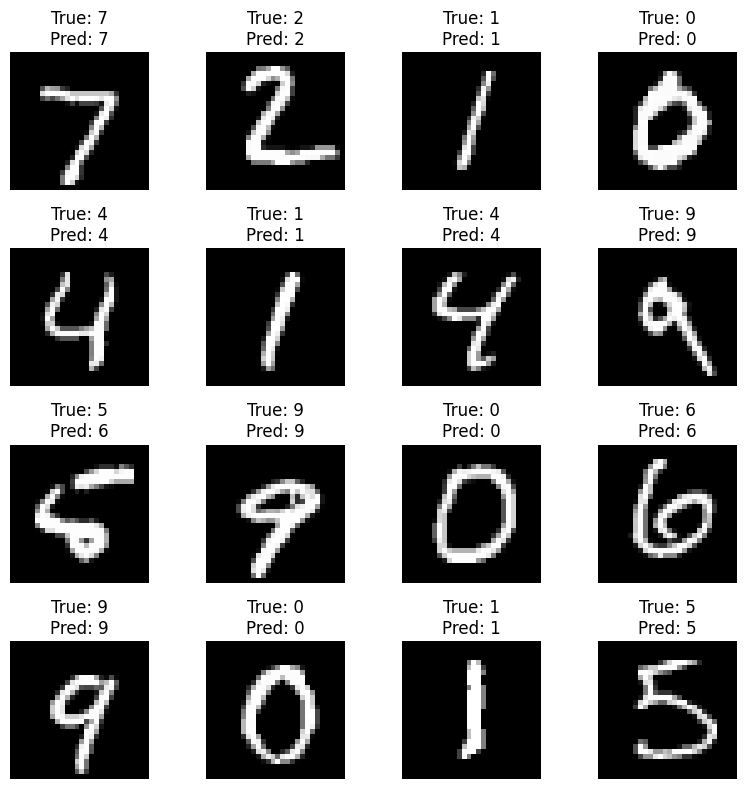

In [48]:
# Visualize some predictions
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, dataset, device, num_images=12, rows=3, cols=4):
    """
    Visualize original images and model predictions.
    
    Args:
        model: The trained transformer model
        dataset: The dataset containing original images (e.g., test_dataset)
        device: The device to run predictions on ('cuda' or 'cpu')
        num_images: Total number of images to display (default: 12)
        rows: Number of rows in the subplot grid (default: 3)
        cols: Number of columns in the subplot grid (default: 4)
    """
    model.eval()
    with torch.no_grad():
        # Create a figure with subplots
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
        axes = axes.ravel()
        
        for i in range(num_images):
            # Get original image and label from dataset
            img, label = dataset[i]
            
            # Create patches for the single image
            patches = create_image_patches(img)
            patches = torch.tensor(patches).unsqueeze(0).float().to(device)  # Add batch dimension
            
            # Get model prediction
            output = model(patches)
            pred = output.argmax(dim=1).item()
            
            # Display original image (not patches)
            img_np = img.squeeze().numpy()  # Remove channel dimension
            axes[i].imshow(img_np, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f'True: {label}\nPred: {pred}')
        
        plt.tight_layout()
        plt.show()

    
# Or with custom parameters:
visualize_predictions(model, test_dataset, device, num_images=16, rows=4, cols=4)


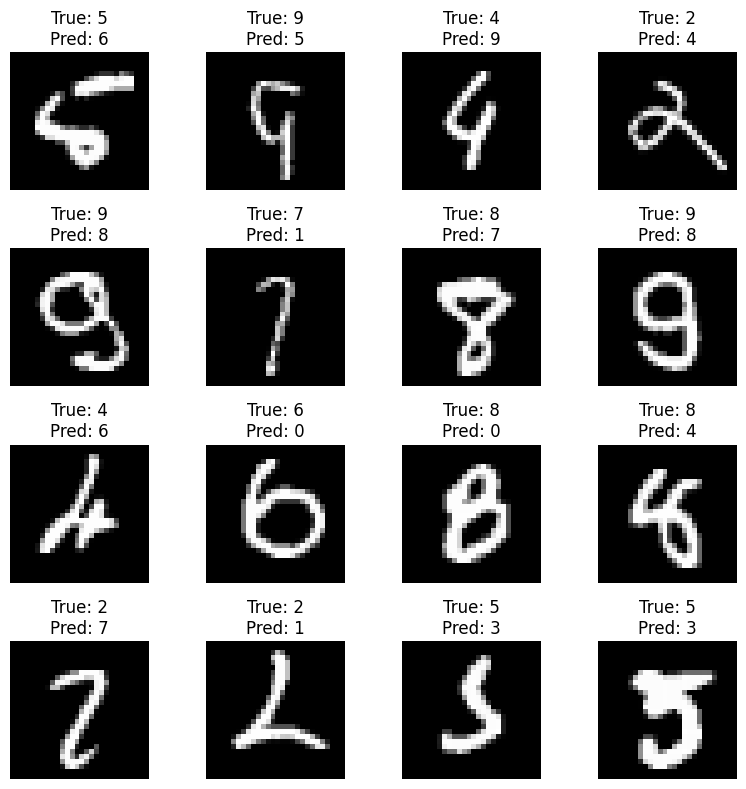

In [49]:
def visualize_incorrect_predictions(model, dataset, device, num_images=12, rows=3, cols=4):
    """
    Visualize only the incorrectly predicted images.
    
    Args:
        model: The trained transformer model
        dataset: The dataset containing original images (e.g., test_dataset)
        device: The device to run predictions on ('cuda' or 'cpu')
        num_images: Total number of incorrect images to display (default: 12)
        rows: Number of rows in the subplot grid (default: 3)
        cols: Number of columns in the subplot grid (default: 4)
    """
    model.eval()
    incorrect = []

    with torch.no_grad():
        for img, label in dataset:
            # Create patches and run model
            patches = create_image_patches(img)
            patches = torch.tensor(patches).unsqueeze(0).float().to(device)
            output = model(patches)
            pred = output.argmax(dim=1).item()

            if pred != label:
                incorrect.append((img, label, pred))
            if len(incorrect) >= num_images:
                break

    # Plotting
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.ravel()
    
    for i in range(len(incorrect)):
        img, label, pred = incorrect[i]
        img_np = img.squeeze().numpy()
        axes[i].imshow(img_np, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'True: {label}\nPred: {pred}')
    
    # Hide unused axes
    for j in range(len(incorrect), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


visualize_incorrect_predictions(model, test_dataset, device, num_images=16, rows=4, cols=4)
